## We will start looking a the experimental hue data a channel at the time. 

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

# where is the hue data we will be looking at? 
expFolder = "data3_grid_10Jun26"
base = Path.home() / "projects" / "metamers" / "hueSensor" / expFolder


# Function helpers, bien aletosos

In [2]:

def summarize_stims(path):
    df = pd.read_csv(path, sep="\t", header=0)

    # 1. Keep exp runs
    df = df[df["Stim"] < 999]

    # 2. Keep only activation periods
    df = df[df["Trig"] == 1]

    # 3. Work only with Stim > 1
    df = df[df["Stim"] >= 1]

    # Prepare output rows
    rows = []

    # 4. Process each Stim separately
    for stim, block in df.groupby("Stim"):

        # Trim first 3 and last 3 samples
        if len(block) < 7:
            # Not enough samples to trim → skip
            continue

        trimmed = block.iloc[3:-3].reset_index(drop=True)

        # Compute means
        meanR = trimmed["HueR"].mean()
        meanG = trimmed["HueG"].mean()
        meanB = trimmed["HueB"].mean()

        # Extract 15th sample (index 14)
        if len(trimmed) > 14:
            red15 = trimmed["Red"].iloc[14]
            green15 = trimmed["Green"].iloc[14]
        else:
            red15 = None
            green15 = None

        rows.append({
            "Stim": stim,
            "meanHueR": meanR,
            "meanHueG": meanG,
            "meanHueB": meanB,
            "reds": red15,
            "greens": green15
        })
    return pd.DataFrame(rows)

def summarize_baselines(path):
    df = pd.read_csv(path, sep="\t", header=0)

    # 1. Keep ONLY baseline rows
    df = df[df["Stim"] == 999]

    # 2. Keep only activation periods
    df = df[df["Trig"] == 1].reset_index(drop=True)

    # 3. Identify contiguous baseline blocks
    # A new block starts whenever the index is not consecutive
    df["block_id"] = (df.index.to_series().diff() != 1).cumsum()

    rows = []

    # 4. Process each baseline block separately
    for block_id, block in df.groupby("block_id"):

        # Trim first 3 and last 3 samples
        if len(block) < 7:
            continue

        trimmed = block.iloc[3:-3].reset_index(drop=True)

        # Compute means
        meanR = trimmed["HueR"].mean()
        meanG = trimmed["HueG"].mean()
        meanB = trimmed["HueB"].mean()

        # Extract 15th sample (index 14)
        if len(trimmed) > 14:
            red15 = trimmed["Red"].iloc[14]
            green15 = trimmed["Green"].iloc[14]
        else:
            red15 = None
            green15 = None

        rows.append({
            "BaselineBlock": block_id,
            "Stim": 999,
            "meanHueR": meanR,
            "meanHueG": meanG,
            "meanHueB": meanB,
            "reds": red15,
            "greens": green15
        })

    return pd.DataFrame(rows)

def plotOneChannelHueVsBase(data, chann):
    baseRed   = 3160
    baseGreen = 1440
    baseBlue  = 815

    df_solid = summarize_stims(data)
    plt.figure(figsize=(10, 5))
    x = df_solid["Stim"]
    if chann == "R":
        plt.plot(x, abs(df_solid["meanHueR"] - baseRed), color="red",   marker="o", label="R")
    elif chann == "G":
        plt.plot(x, abs(df_solid["meanHueG"] - baseGreen), color="green",   marker="o", label="G")
    elif chann == "B":
        plt.plot(x, abs(df_solid["meanHueB"] - baseBlue), color="blue",   marker="o", label="B")
    else: 
        return 0
    plt.xlabel("StimNumber")
    plt.ylabel("Mean Hue Value")
    plt.title("Hue yellow substracted")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plotHueDistanceVsBase(data):
    baseRed   = 3160
    baseGreen = 1440
    baseBlue  = 815

    df_solid = summarize_stims(data)

    # Compute Euclidean distance to baseline
    df_solid["dist"] = np.sqrt(
        (df_solid["meanHueR"] - baseRed)**2 +
        (df_solid["meanHueG"] - baseGreen)**2 +
        (df_solid["meanHueB"] - baseBlue)**2
    )

    plt.figure(figsize=(10, 5))
    x = df_solid["Stim"]

    plt.plot(x, df_solid["dist"], color="black", marker="o", label="Euclidean distance")

    plt.xlabel("StimNumber")
    plt.ylabel("Distance from baseline")
    plt.title("Hue deviation from baseline (Euclidean distance)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def dist_euclidean(vec, base):
    return np.sqrt(np.sum((vec - base)**2))

def dist_manhattan(vec, base):
    return np.sum(np.abs(vec - base))

def dist_normalized(vec, base, scale):
    return np.sqrt(np.sum(((vec - base) / scale)**2))

def dist_angle(vec, base):
    # angle between vectors in degrees
    dot = np.dot(vec, base)
    norm = np.linalg.norm(vec) * np.linalg.norm(base)
    if norm == 0:
        return np.nan
    return np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

def dist_mahalanobis(vec, base, cov_inv):
    diff = vec - base
    return np.sqrt(diff.T @ cov_inv @ diff)

def get_stim_vector(row, channels="RGB"):
    if channels == "RGB":
        return np.array([row["meanHueR"], row["meanHueG"], row["meanHueB"]])
    elif channels == "RG":
        return np.array([row["meanHueR"], row["meanHueG"]])
    else:
        raise ValueError("channels must be 'RGB' or 'RG'")

def compute_stim_distance(df_solid, 
                          baseR=3160, baseG=1440, baseB=815,
                          channels="RGB",
                          metric="euclidean",
                          scale=None,
                          cov_inv=None):

    # Select baseline vector
    if channels == "RGB":
        base = np.array([baseR, baseG, baseB])
    elif channels == "RG":
        base = np.array([baseR, baseG])
    else:
        raise ValueError("channels must be 'RGB' or 'RG'")

    distances = []

    for _, row in df_solid.iterrows():
        vec = get_stim_vector(row, channels)

        if metric == "euclidean":
            d = dist_euclidean(vec, base)

        elif metric == "manhattan":
            d = dist_manhattan(vec, base)

        elif metric == "normalized":
            if scale is None:
                raise ValueError("scale must be provided for normalized distance")
            d = dist_normalized(vec, base, scale)

        elif metric == "angle":
            d = dist_angle(vec, base)

        elif metric == "mahalanobis":
            if cov_inv is None:
                raise ValueError("cov_inv must be provided for Mahalanobis distance")
            d = dist_mahalanobis(vec, base, cov_inv)

        else:
            raise ValueError("Unknown metric")

        distances.append(d)

    df_solid = df_solid.copy()
    df_solid["distance"] = distances
    return df_solid

def plot_stim_distance(data, 
                       channels="RGB",
                       metric="euclidean",
                       scale=None,
                       cov_inv=None):

    df_solid = summarize_stims(data)

    df_dist = compute_stim_distance(
        df_solid,
        channels=channels,
        metric=metric,
        scale=scale,
        cov_inv=cov_inv
    )

    plt.figure(figsize=(10, 5))
    plt.plot(df_dist["Stim"], df_dist["distance"], 
             color="black", marker="o",
             label=f"{metric} ({channels})")

    plt.xlabel("StimNumber")
    plt.ylabel("Distance from baseline")
    plt.title(f"{metric.capitalize()} distance from baseline ({channels})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return df_dist

def attach_ssvep_to_hue(df_hue, mean_ssvep, red_axis, green_axis):
    """
    df_hue: dataframe with columns 'reds', 'greens'
    mean_ssvep: 10x10 array indexed as [redIndex, greenIndex]
    red_axis: 1D array of length 10 (data['Reds'])
    green_axis: 1D array of length 10 (data['Greens'])
    """

    ssvep_vals = []

    for _, row in df_hue.iterrows():
        r = row["reds"]
        g = row["greens"]

        # find closest red index
        i_red = np.argmin(np.abs(red_axis - r))

        # find closest green index
        j_green = np.argmin(np.abs(green_axis - g))

        # grab ssvep value at that grid point
        #val = mean_ssvep[i_red, j_green]
        val = mean_ssvep[j_green, i_red]
        ssvep_vals.append(val)

    df_hue_ssvep = df_hue.copy()
    df_hue_ssvep["mean_ssvep"] = ssvep_vals

    return df_hue_ssvep

def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    xmin = np.min(x)
    xmax = np.max(x)
    if xmax == xmin:
        return np.zeros_like(x)   # avoid division by zero
    return (x - xmin) / (xmax - xmin)

redArray   = np.linspace(0, 3200, 10)
greenArray = np.linspace(0, 2000, 10)

def stim_to_grid_index(red, green, redArray, greenArray):
    i = np.argmin(np.abs(redArray - red))     # column index
    j = np.argmin(np.abs(greenArray - green)) # row index
    return j, i

def build_distance_grid(df, redArray, greenArray):
    grid = np.zeros((10, 10))

    for _, row in df.iterrows():
        j, i = stim_to_grid_index(row["reds"], row["greens"], redArray, greenArray)
        grid[j, i] = row["distance"]

    return grid

def plot_distance_grid(grid, redArray, greenArray, title="Distance Grid"):
    plt.figure(figsize=(7, 6))

    plt.imshow(grid, origin="lower", cmap="viridis")

    # Add colorbar
    plt.colorbar(label="Distance")

    # Set tick positions (0–9)
    plt.xticks(ticks=np.arange(len(redArray)), labels=[f"{v:.0f}" for v in redArray])
    plt.yticks(ticks=np.arange(len(greenArray)), labels=[f"{v:.0f}" for v in greenArray])

    plt.xlabel("Red value")
    plt.ylabel("Green value")
    plt.title(title)

    plt.tight_layout()
    plt.show()

def plot_stim_distance_grid(path,
                            channels="RG",
                            metric="euclidean",
                            scale=None,
                            cov_inv=None):

    # 1. Summaries
    df = summarize_stims(path)

    # 2. Compute distance
    df = compute_stim_distance(df,
                               channels=channels,
                               metric=metric,
                               scale=scale,
                               cov_inv=cov_inv)

    # 3. Build grid
    redArray   = np.linspace(0, 3200, 10)
    greenArray = np.linspace(0, 2000, 10)
    grid = build_distance_grid(df, redArray, greenArray)

    # 4. Plot with real ticks
    title = f"{metric.capitalize()} distance grid ({channels})"
    plot_distance_grid(grid, redArray, greenArray, title)


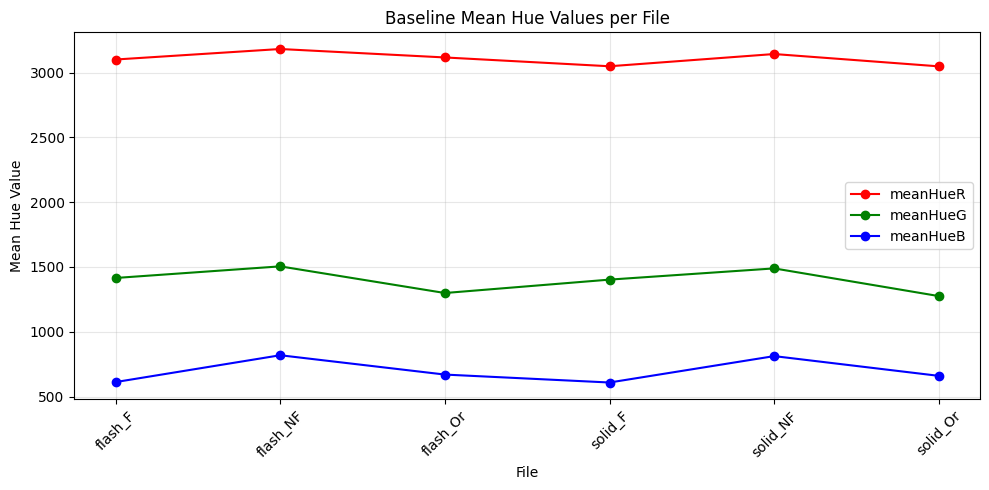

In [3]:
fileNams = ["flash_F", "flash_NF", "flash_Or",
            "solid_F", "solid_NF", "solid_Or"]

all_rows = []

for fi in fileNams:
    currFile = base / f"{fi}.txt"
    df_base = summarize_baselines(currFile)

    # Add filename to each row
    df_base = df_base.copy()
    df_base["File"] = fi

    all_rows.append(df_base)

# Final combined dataframe
df_all_baselines = pd.concat(all_rows, ignore_index=True)

df_all_baselines

df_plot = (
    df_all_baselines
    .groupby("File")[["meanHueR", "meanHueG", "meanHueB"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

x = df_plot["File"]

plt.plot(x, df_plot["meanHueR"], color="red",   marker="o", label="meanHueR")
plt.plot(x, df_plot["meanHueG"], color="green", marker="o", label="meanHueG")
plt.plot(x, df_plot["meanHueB"], color="blue",  marker="o", label="meanHueB")

plt.xlabel("File")
plt.ylabel("Mean Hue Value")
plt.title("Baseline Mean Hue Values per File")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


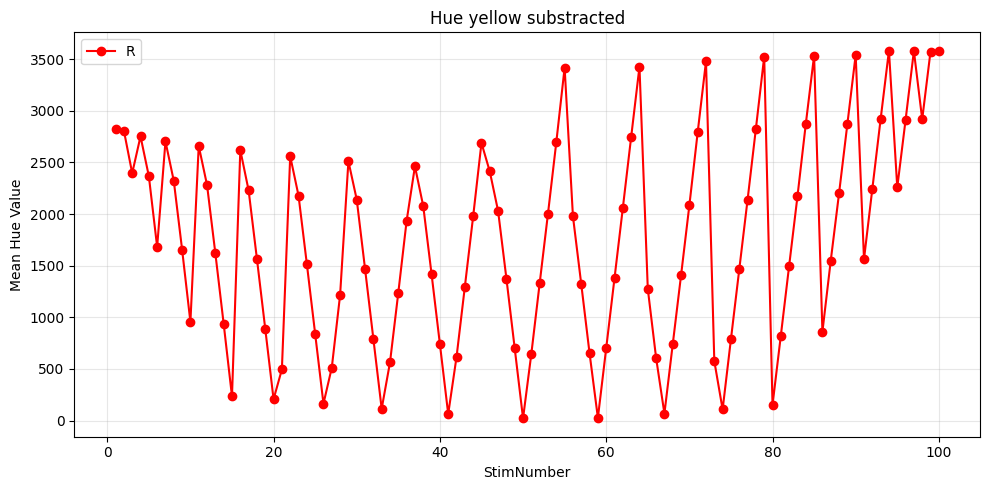

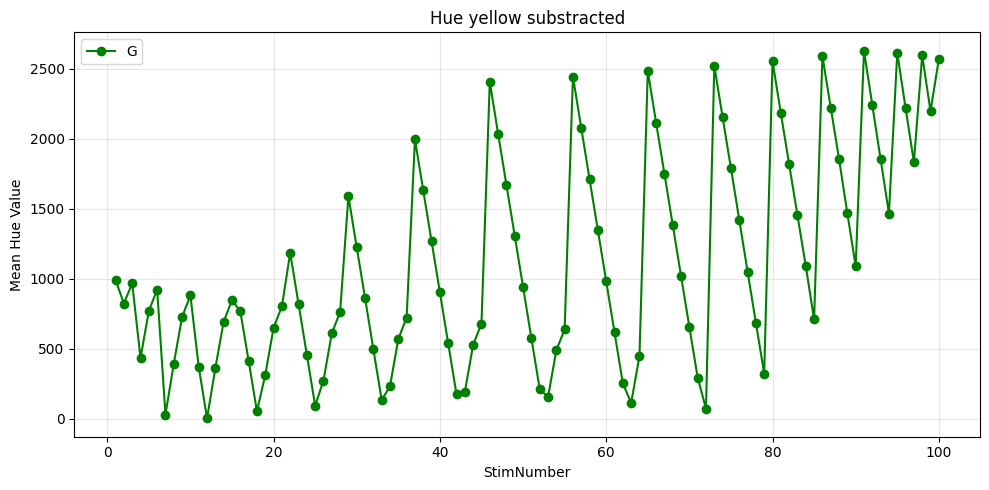

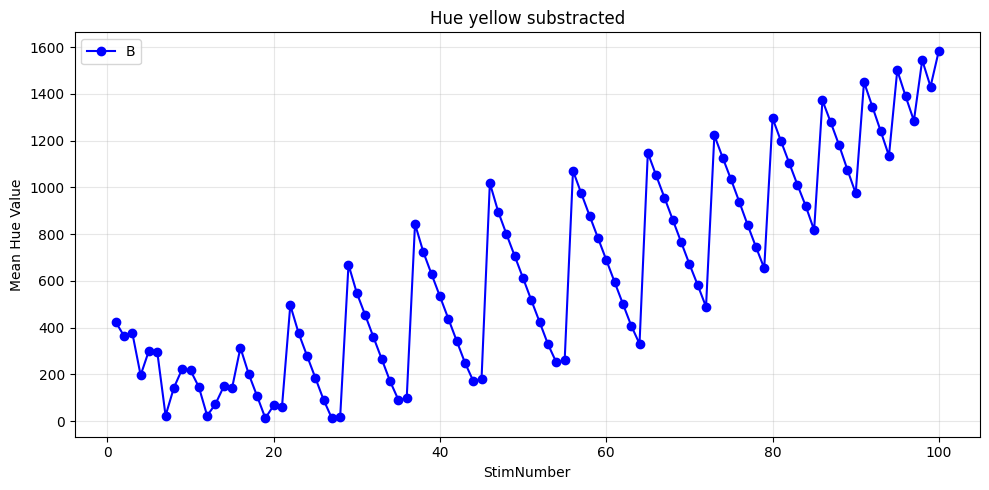

In [4]:
baseRed   = 3160
baseGreen = 1440
baseBlue  = 815

solid =  base / "solid_NF.txt" 
flash = base / "flash_NF.txt"

plotOneChannelHueVsBase(solid, "R")
plotOneChannelHueVsBase(solid, "G")
plotOneChannelHueVsBase(solid, "B")

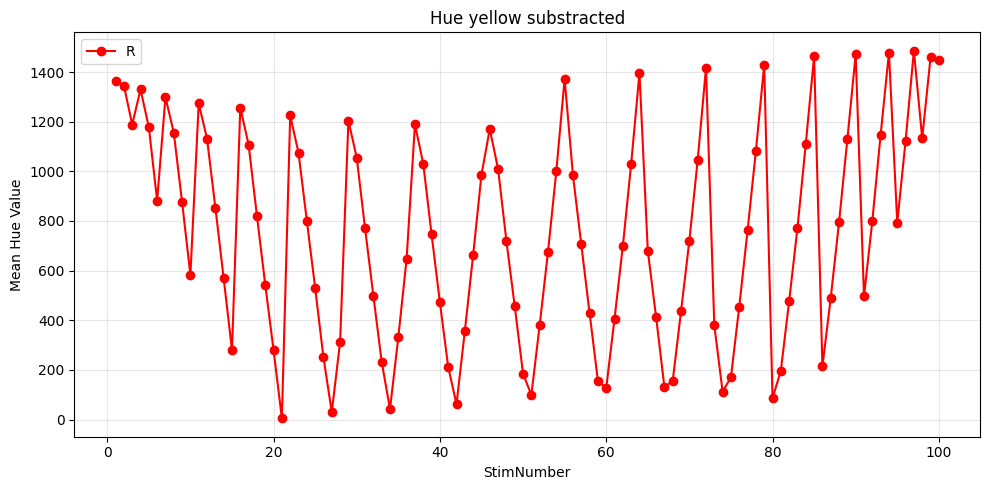

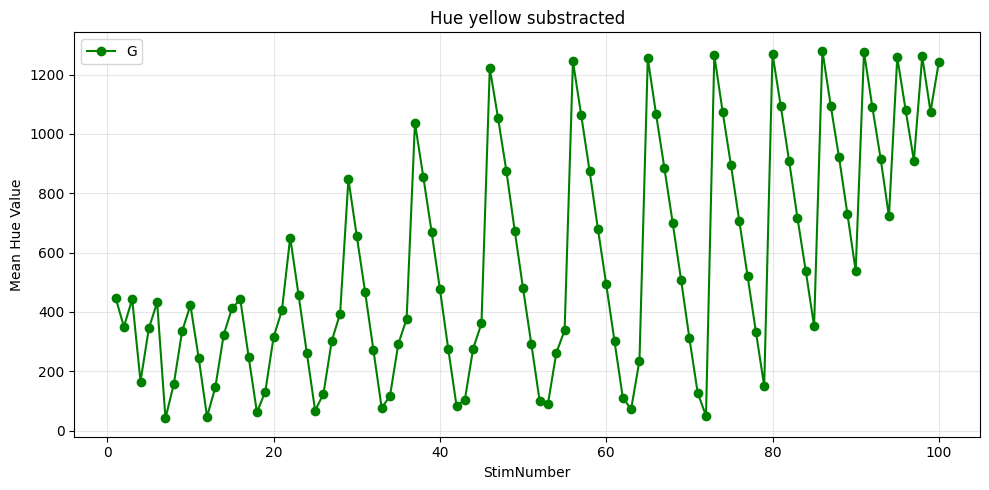

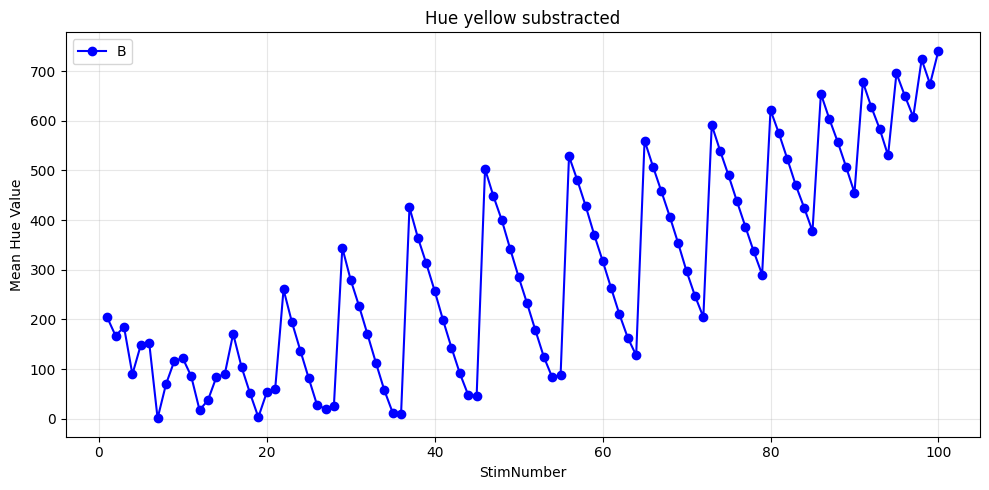

In [5]:
plotOneChannelHueVsBase(flash, "R")
plotOneChannelHueVsBase(flash, "G")
plotOneChannelHueVsBase(flash, "B")

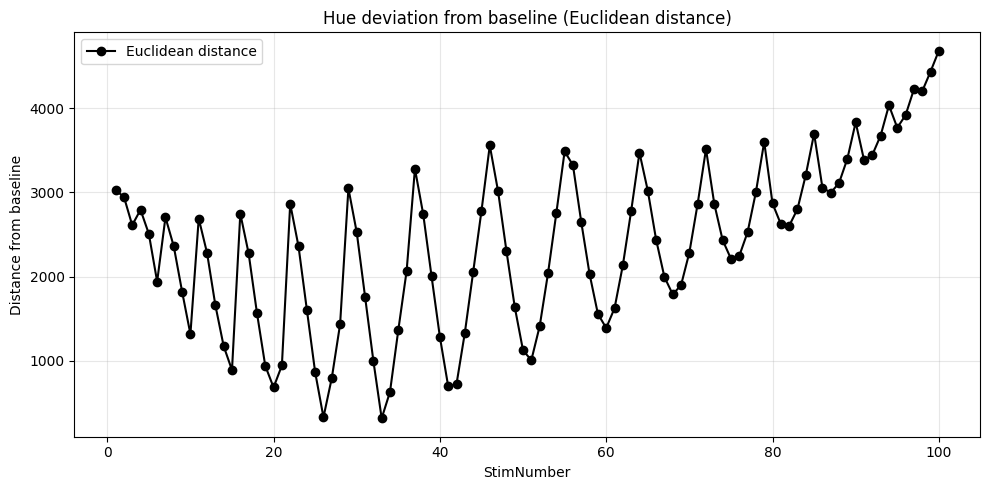

In [7]:
plotHueDistanceVsBase(solid)


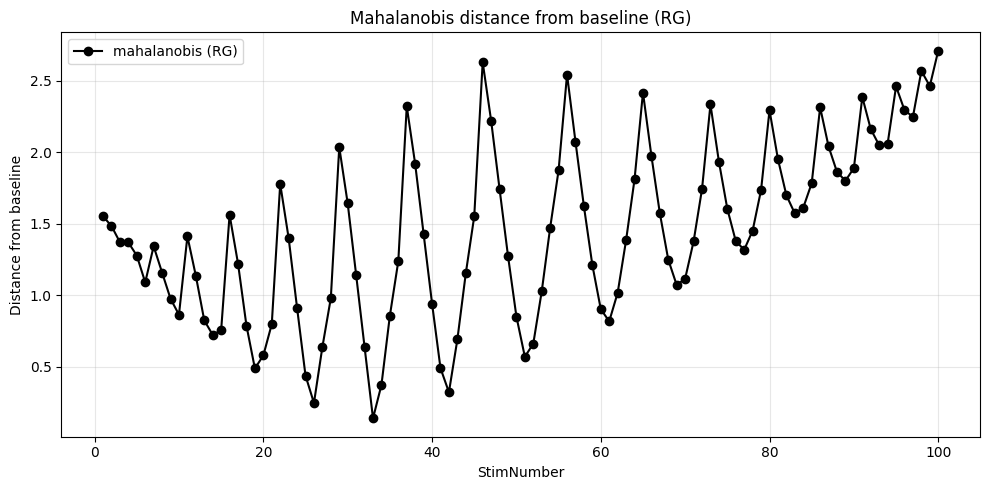

,Stim,meanHueR,meanHueG,meanHueB,reds,greens,distance
0,1,336.095238,449.000000,391.238095,0,0,1.552208
1,2,352.047619,617.047619,450.476190,0,222,1.484299
2,3,764.523810,472.809524,437.904762,355,0,1.371135
3,4,408.000000,1007.090909,618.954545,0,444,1.369113
4,5,792.272727,670.181818,513.500000,355,222,1.277986
...,...,...,...,...,...,...,...
95,96,6071.000000,3660.714286,2205.333333,2844,1777,2.294363
96,97,6738.904762,3273.714286,2100.238095,3200,1555,2.247294
97,98,6077.904762,4035.857143,2359.761905,2844,2000,2.568630
98,99,6734.095238,3636.952381,2246.333333,3200,1777,2.462370


In [8]:
df_solid = summarize_stims(solid)
cov = np.cov(df_solid[["meanHueR","meanHueG"]].values.T)
cov_inv = np.linalg.inv(cov)

plot_stim_distance(solid, channels="RG", metric="mahalanobis", cov_inv=cov_inv)


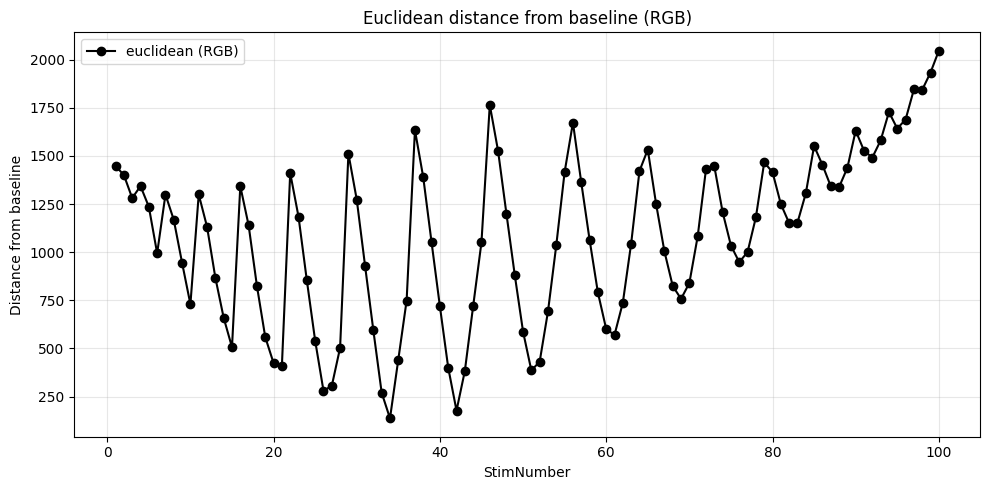

    Stim     meanHueR     meanHueG     meanHueB  reds  greens     distance
0      1  1797.794872   992.205128   610.897436     0       0  1448.371815
1      2  1814.230769  1089.743590   648.000000     0     222  1400.593937
2      3  1971.769231   997.794872   629.871795   355       0  1281.292390
3      4  1829.948718  1274.589744   725.538462     0     444  1343.279693
4      5  1982.076923  1095.615385   666.358974   355     222  1236.202934
..   ...          ...          ...          ...   ...     ...          ...
95    96  4282.410256  2521.923077  1465.153846  2844    1777  1689.101048
96    97  4645.897436  2349.974359  1422.794872  3200    1555  1845.361517
97    98  4292.948718  2701.358974  1538.461538  2844    2000  1843.365362
98    99  4618.769231  2514.820513  1488.974359  3200    1777  1933.258451
99   100  4607.923077  2682.282051  1556.051282  3200    2000  2046.680956

[100 rows x 7 columns]


In [9]:
distflash = plot_stim_distance(flash, channels="RGB", metric="euclidean")
print(distflash)

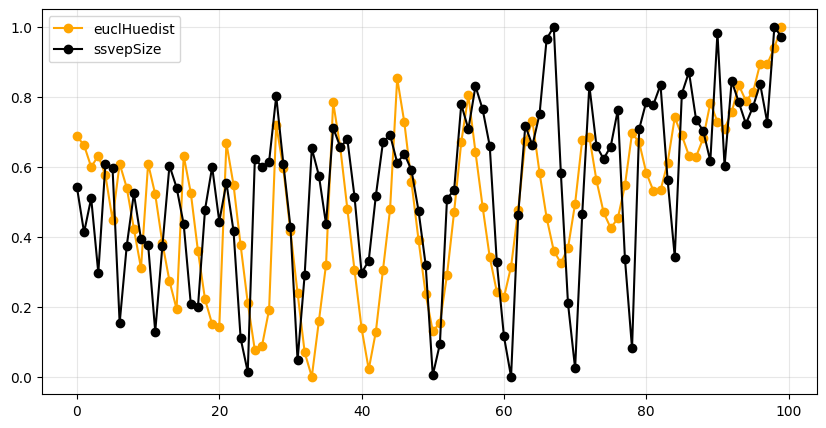

In [12]:
from metamers.eeg.ssvep2python import load_ssvep_npz
from metamers.eeg.ssvep_plotting import *

data = load_ssvep_npz("/home/zevaz/projects/metamers/eeg/ssveps/MET017.npz")
ssvep = data["run_map"]
ssvep_mean = ssvep.mean(axis=2)

df_flash = summarize_stims(flash)
df_hue_ssvepFlash= attach_ssvep_to_hue(df_flash,ssvep_mean, data["red_array"], data["green_array"])

plt.figure(figsize=(10, 5))
plt.plot(minmax_scale(distflash["distance"]), color="orange",   marker="o", label="euclHuedist")
plt.plot(minmax_scale(df_hue_ssvepFlash["mean_ssvep"]), color="black",   marker="o", label="ssvepSize")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

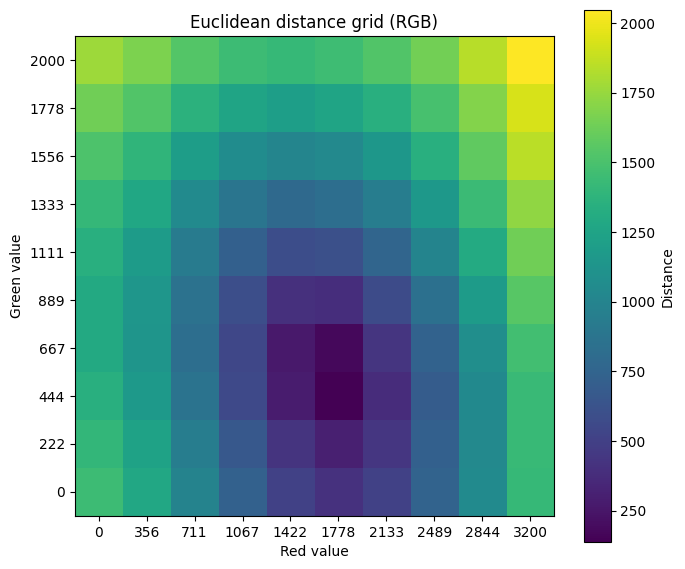

In [13]:
plot_stim_distance_grid(flash,
                            channels="RGB",
                            metric="euclidean")

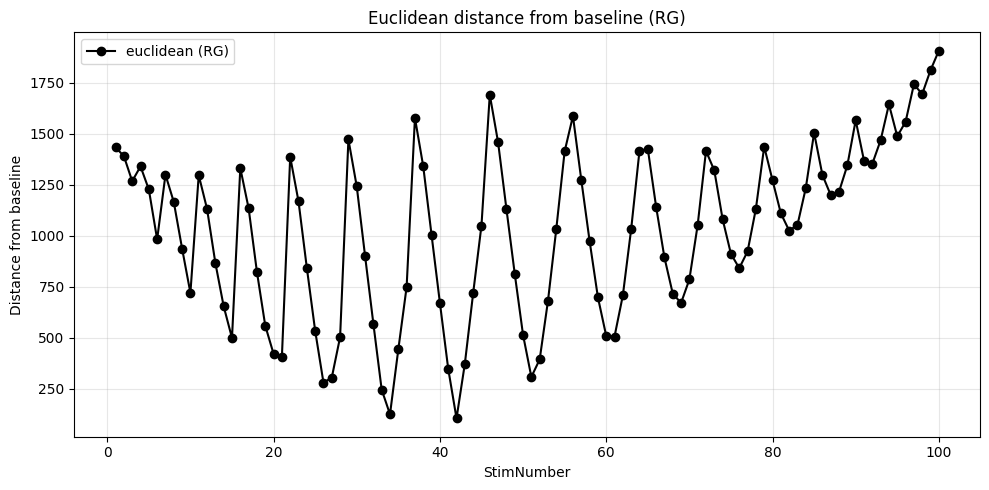

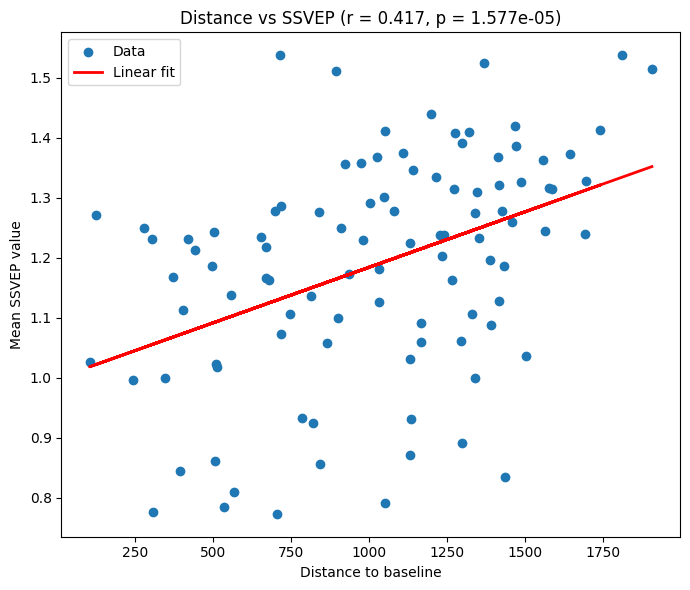

In [14]:
from scipy.stats import pearsonr


def plot_distance_vs_ssvep(dist_df, ssvep_df):
    x = dist_df["distance"].values
    y = ssvep_df["mean_ssvep"].values

    # --- Correlation ---
    r, p = pearsonr(x, y)

    # --- Linear fit ---
    slope, intercept = np.polyfit(x, y, 1)
    y_fit = slope * x + intercept

    # --- Plot ---
    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, marker="o", label="Data")

    # Add fitted line
    plt.plot(x, y_fit, color="red", linewidth=2, label="Linear fit")

    plt.xlabel("Distance to baseline")
    plt.ylabel("Mean SSVEP value")

    plt.title(f"Distance vs SSVEP (r = {r:.3f}, p = {p:.3e})")

    plt.legend()
    plt.tight_layout()
    plt.show()

distflash = plot_stim_distance(flash, channels="RG", metric="euclidean")
plot_distance_vs_ssvep(distflash, df_hue_ssvepFlash)


In [23]:
# from scipy.stats import spearmanr

# def plot_distance_vs_ssvep_spearman(dist_df, ssvep_df):
#     x = dist_df["distance"].values
#     y = ssvep_df["mean_ssvep"].values

#     # --- Spearman correlation ---
#     rho, p = spearmanr(x, y)

#     # --- Linear fit (for visualization only) ---
#     slope, intercept = np.polyfit(x, y, 1)
#     y_fit = slope * x + intercept

#     # --- Plot ---
#     plt.figure(figsize=(7, 6))
#     plt.scatter(x, y, marker="o", label="Data")

#     # Add fitted line
#     plt.plot(x, y_fit, color="red", linewidth=2, label="Linear fit")

#     plt.xlabel("Distance to baseline")
#     plt.ylabel("Mean SSVEP value")

#     plt.title(f"Distance vs SSVEP (Spearman ρ = {rho:.3f}, p = {p:.3e})")

#     plt.legend()
#     plt.tight_layout()
#     plt.show()



# distflash = plot_stim_distance(flash, channels="RG", metric="euclidean")
# plot_distance_vs_ssvep_spearman(distflash, df_hue_ssvepFlash)
